In [1]:
import numpy as np
import xarray as xr
import matplotlib
import matplotlib.pyplot as plt
import holoviews as hv
import scienceplots # matplotlib styles

In [ ]:
# Download data files from Zenodo if not cached locally
import os
import urllib.request

ZENODO_BASE = "https://zenodo.org/records/19680005/files"
DATA_DIR = "data"

def fetch_zenodo(filename):
    os.makedirs(DATA_DIR, exist_ok=True)
    local_path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(local_path):
        url = f"{ZENODO_BASE}/{filename}?download=1"
        print(f"Downloading {filename} from Zenodo...")
        urllib.request.urlretrieve(url, local_path)
    return local_path

In [2]:
print(hv.__version__)
print(np.__version__)
print(matplotlib.__version__)

1.21.0
2.3.1
3.10.3


In [3]:
# Basic options for plotting figure for the paper
plt.style.use(['science', 'no-latex', 'nature', 'std-colors'])
matplotlib.rcParams['pdf.fonttype'] = 42 # use type 2 fonts
matplotlib.rcParams['ps.fonttype'] = 42 # use type 2 fonts
plt.rcParams['svg.fonttype'] = 'none'  # makes editable fonts in inkscape

In [ ]:
# load the partial radial distribution functions calculated by OVITO
zrte5_freestanding_rdf = np.loadtxt(fetch_zenodo('rdf_monolayer_freestanding.txt'))
zrte5_ongold_rdf = np.loadtxt(fetch_zenodo('rdf_monolayer.txt'))

# load data for bilayer
zrte5_bilayer_near_rdf = np.loadtxt(fetch_zenodo('rdf_bilayer_neargold.txt'))
zrte5_bilayer_far_rdf = np.loadtxt(fetch_zenodo('rdf_bilayer_fargold.txt'))
# monolayer full RDF for comparison
zrte5_freestanding_fullrdf = np.loadtxt(fetch_zenodo('rdf_monolayer_fullrdf.txt'))

# load the partial RDF for the bilayer as well
zrte5_bilayer_near_rdf_partial = np.loadtxt(fetch_zenodo('rdf_bilayer_neargold_partial.txt'))
zrte5_bilayer_far_rdf_partial = np.loadtxt(fetch_zenodo('rdf_bilayer_fargold_partial.txt'))

In [5]:
# Extract the r coordinate from the first column
r = zrte5_freestanding_rdf[:, 0]
# Define the atom pair labels for the columns
atom_pairs = ["Zr-Zr", "Zr-Te", "Te-Te"]
# Create the xarray DataArray with dimensions 'r' and 'atom_pairs'
rdf_da = xr.DataArray(
    zrte5_freestanding_rdf[:, 1:] / zrte5_freestanding_rdf[:, 1:].sum(), # normalize the values
    dims=['r', 'atom pairs'],
    coords={'r': r, 'atom pairs': atom_pairs},
)

rdf_da.attrs['long_name'] = 'g(r)'
rdf_da.attrs['name'] = 'partial radial distribution function'
rdf_da.r.attrs['units'] = r'$\AA$'
rdf_da.r.attrs['long_name'] = 'pair separation distance'

In [6]:
# Extract the r coordinate from the first column
r = zrte5_ongold_rdf[:, 0]
# Define the atom pair labels for the columns
atom_pairs = ["Zr-Zr", "Zr-Te", "Te-Te"]
# Create the xarray DataArray with dimensions 'r' and 'atom_pairs'
rdf_ongold_da = xr.DataArray(
    zrte5_ongold_rdf[:, 1:] / zrte5_ongold_rdf[:, 1:].sum(), # normalize the values
    dims=['r', 'atom pairs'],
    coords={'r': r, 'atom pairs': atom_pairs},
)

rdf_ongold_da.attrs['long_name'] = 'g(r)'
rdf_ongold_da.attrs['name'] = 'partial radial distribution function'
rdf_ongold_da.r.attrs['units'] = r'$\AA$'
rdf_ongold_da.r.attrs['long_name'] = 'pair separation distance'

In [7]:
# Extract the r coordinate from the first column
r = zrte5_bilayer_near_rdf_partial[:, 0]
# Define the atom pair labels for the columns
atom_pairs = ["Zr-Zr", "Zr-Te", "Te-Te"]
# Create the xarray DataArray with dimensions 'r' and 'atom_pairs'
rdf_bi_near_da = xr.DataArray(
    zrte5_bilayer_near_rdf_partial[:, 1:] / zrte5_bilayer_near_rdf_partial[:, 1:].sum(), # normalize the values
    dims=['r', 'atom pairs'],
    coords={'r': r, 'atom pairs': atom_pairs},
)

rdf_bi_near_da.attrs['long_name'] = 'g(r)'
rdf_bi_near_da.attrs['name'] = 'partial radial distribution function'
rdf_bi_near_da.r.attrs['units'] = r'$\AA$'
rdf_bi_near_da.r.attrs['long_name'] = 'pair separation distance'

# Extract the r coordinate from the first column
r = zrte5_bilayer_far_rdf_partial[:, 0]
# Define the atom pair labels for the columns
atom_pairs = ["Zr-Zr", "Zr-Te", "Te-Te"]
# Create the xarray DataArray with dimensions 'r' and 'atom_pairs'
rdf_bi_far_da = xr.DataArray(
    zrte5_bilayer_far_rdf_partial[:, 1:] / zrte5_bilayer_far_rdf_partial[:, 1:].sum(), # normalize the values
    dims=['r', 'atom pairs'],
    coords={'r': r, 'atom pairs': atom_pairs},
)

rdf_bi_far_da.attrs['long_name'] = 'g(r)'
rdf_bi_far_da.attrs['name'] = 'partial radial distribution function'
rdf_bi_far_da.r.attrs['units'] = r'$\AA$'
rdf_bi_far_da.r.attrs['long_name'] = 'pair separation distance'

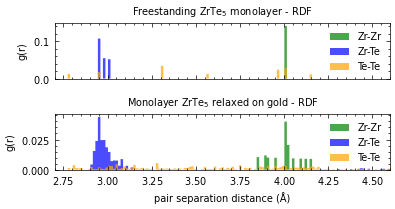

In [8]:
bins = 700
# Set global font size to 7 for all text elements
plt.rcParams.update({'font.size': 7})  # Set default font size

# Plot the two DataArrays in separate subplots, one above the other
fig, axes = plt.subplots(2, 1, figsize=(4, 2.2), sharex=True)

# Set titles with font size 7
axes[0].set_title('Freestanding ZrTe$_5$ monolayer - RDF', fontsize=7)
axes[1].set_title('Monolayer ZrTe$_5$ relaxed on gold - RDF', fontsize=7)

# Define custom colors for each atom pair
pair_colors = {"Zr-Zr": "green", "Zr-Te": "blue", "Te-Te": "orange"}

# Loop over both DataArrays and plot histograms for each atom pair with correct color mapping
for i, da in enumerate([rdf_da, rdf_ongold_da]):
    for j, pair in enumerate(da.coords['atom pairs'].values):
        axes[i].hist(
            da['r'].values,
            bins=bins,
            weights=da.isel({'atom pairs': j}).values,
            alpha=0.7,
            color=pair_colors.get(pair, "gray"),
            label=pair,
            histtype='stepfilled'
        )
    # Remove the border from the legend by setting frameon=False
    axes[i].legend(fontsize=7, frameon=False)  # Set legend font size and remove border
    axes[i].tick_params(axis='both', which='major', labelsize=7)  # Set tick label font size

plt.xlabel('pair separation distance (Å)', fontsize=7)
axes[0].set_ylabel('g(r)', fontsize=7)
axes[1].set_ylabel('g(r)', fontsize=7)
# plt.xlim(2.5, 6)
plt.xlim(2.7, 4.6)
plt.yscale('linear')
plt.tight_layout()
plt.savefig('rdf.svg')

In [9]:
r_mono, gr_mono = zrte5_freestanding_fullrdf[:, 0], zrte5_freestanding_fullrdf[:, 1]
r_bi, gr_bi_near = zrte5_bilayer_near_rdf[:, 0], zrte5_bilayer_near_rdf[:, 1]
r_bi, gr_bi_far = zrte5_bilayer_far_rdf[:, 0], zrte5_bilayer_far_rdf[:, 1]

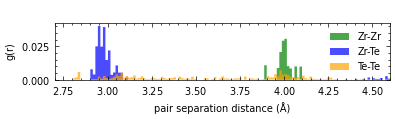

In [10]:
bins = 700
# Set global font size to 7 for all text elements
plt.rcParams.update({'font.size': 7})  # Set default font size

# Plot the two DataArrays in separate subplots, one above the other
fig, axes = plt.subplots(1, 1, figsize=(4, 1.3), sharex=True)

# Define custom colors for each atom pair
pair_colors = {"Zr-Zr": "green", "Zr-Te": "blue", "Te-Te": "orange"}

for j, pair in enumerate(rdf_bi_near_da.coords['atom pairs'].values):
    plt.hist(
        rdf_bi_near_da['r'].values,
        bins=bins,
        weights=rdf_bi_near_da.isel({'atom pairs': j}).values,
        alpha=0.7,
        color=pair_colors.get(pair, "gray"),
        label=pair,
        histtype='stepfilled'
    )

plt.xlabel('pair separation distance (Å)', fontsize=7)
plt.ylabel('g(r)', fontsize=7)
plt.title(' ')
plt.legend(fontsize=7, frameon=False)
plt.xlim(2.7, 4.6)
plt.yscale('linear')
# ax = plt.gca()
# ax.tick_params(labelbottom=False)
plt.tight_layout()
plt.savefig('rdf_bi-near_partial.svg')

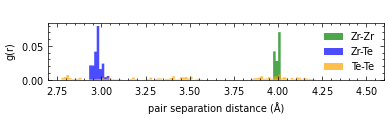

In [11]:
bins = 700
# Set global font size to 7 for all text elements
plt.rcParams.update({'font.size': 7})  # Set default font size

# Plot the two DataArrays in separate subplots, one above the other
fig, axes = plt.subplots(1, 1, figsize=(4, 1.3), sharex=True)

# Define custom colors for each atom pair
pair_colors = {"Zr-Zr": "green", "Zr-Te": "blue", "Te-Te": "orange"}

for j, pair in enumerate(rdf_bi_far_da.coords['atom pairs'].values):
    plt.hist(
        rdf_bi_far_da['r'].values,
        bins=bins,
        weights=rdf_bi_far_da.isel({'atom pairs': j}).values,
        alpha=0.7,
        color=pair_colors.get(pair, "gray"),
        label=pair,
        histtype='stepfilled'
    )

plt.xlabel('pair separation distance (Å)', fontsize=7)
plt.ylabel('g(r)', fontsize=7)
plt.title(' ')
plt.legend(fontsize=7, frameon=False)
plt.xlim(2.7, 4.6)
plt.yscale('linear')
# ax = plt.gca()
# ax.tick_params(labelbottom=False)
plt.tight_layout()
plt.savefig('rdf_bi-far_partial.svg')